
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [2]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2


**Reflection:** I would use `month`, `region`, `store_id`/`store_city`, `category`, and `product` as categorical or time filters, with ranges on `unit_price`, `units_sold`, `revenue`, `profit`, and `avg_rating`. I would link views with stable keys such as `store_id`, `product`, `category`, and `month`, so selecting a store or product highlights the same records in every view.


## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


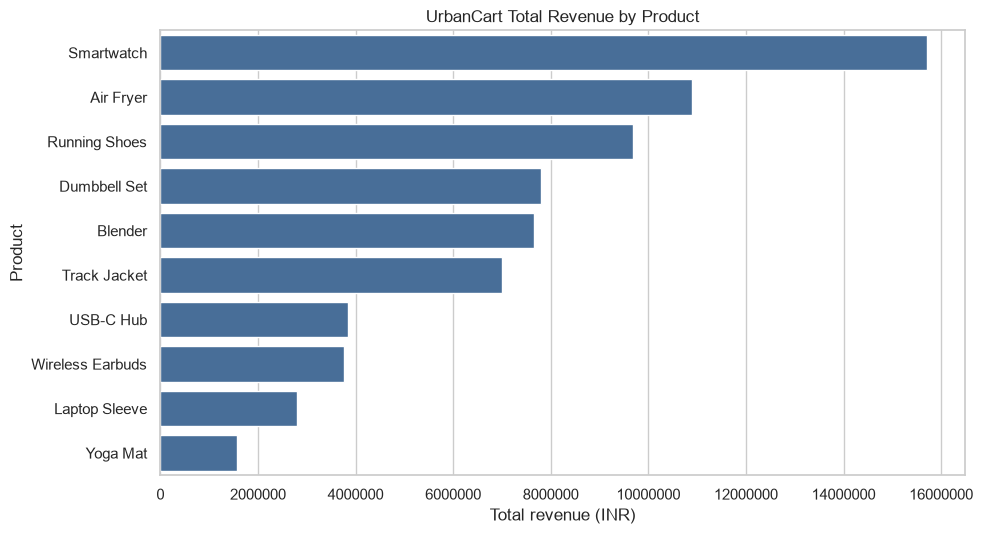

In [3]:
# --- 1a. STATIC chart ---
revenue_by_product = (
    sales_df.groupby(["product", "category"], as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=revenue_by_product,
    x="revenue",
    y="product",
    color="#3b6ea5",
    ax=ax,
)
ax.set_title("UrbanCart Total Revenue by Product")
ax.set_xlabel("Total revenue (INR)")
ax.set_ylabel("Product")
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

In [4]:
# --- 1b. INTERACTIVE chart ---
interactive_revenue_chart = px.bar(
    revenue_by_product,
    x="revenue",
    y="product",
    color="category",
    orientation="h",
    hover_data={"category": True, "revenue": ":,.0f"},
    category_orders={"product": revenue_by_product["product"].tolist()[::-1]},
    title="UrbanCart Total Revenue by Product",
    labels={"revenue": "Total revenue (INR)", "product": "Product"},
)
interactive_revenue_chart.update_layout(height=560)
interactive_revenue_chart.show()

**Your 1-2 sentence answer:**

The interactive chart is the better fit because the manager can read the headline ranking and retrieve an exact revenue value and category on demand through hover. That small interaction cost has clear value for this audience because it eliminates a follow-up lookup without hiding the overall story.


## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


In [5]:
price_slider = widgets.FloatRangeSlider(
    value=(float(sales_df.unit_price.min()), float(sales_df.unit_price.max())),
    min=float(sales_df.unit_price.min()),
    max=float(sales_df.unit_price.max()),
    step=100,
    description="Price",
    continuous_update=True,
    readout_format=".0f",
    layout=widgets.Layout(width="600px"),
)

units_slider = widgets.IntRangeSlider(
    value=(int(sales_df.units_sold.min()), int(sales_df.units_sold.max())),
    min=int(sales_df.units_sold.min()),
    max=int(sales_df.units_sold.max()),
    step=1,
    description="Units",
    continuous_update=True,
    layout=widgets.Layout(width="600px"),
)

def dynamic_filter(price_range, units_range):
    match = sales_df.unit_price.between(*price_range) & sales_df.units_sold.between(*units_range)
    filtered = sales_df.loc[match]
    print(f"{len(filtered):,} / {len(sales_df):,} rows match")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(sales_df.unit_price, sales_df.units_sold, color="#c9c9c9", alpha=0.35, s=20, label="Other rows")
    ax.scatter(filtered.unit_price, filtered.units_sold, color="#d95f02", alpha=0.75, s=28, label="Matching rows")
    ax.set_xlabel("Unit price (INR)")
    ax.set_ylabel("Units sold")
    ax.set_title("Dynamic Product and Sales Filter")
    ax.legend()
    plt.tight_layout()
    plt.show()

dynamic_query = interact(
    dynamic_filter,
    price_range=price_slider,
    units_range=units_slider,
)

interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), description='Price', layout=Layout(width='600px'…

**Reflection:** At 50 times the current 1,440 rows, the data would contain about 72,000 points, so two sliders still fit the lecture's rough computational limit. The scatter plot would nevertheless suffer from overplotting, so I would aggregate the data and use coordinated views with brushing to inspect selected stores or products rather than draw every record at once.


## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


In [6]:
store_overview = (
    sales_df.groupby("store_id", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

def store_coordinated_view(selected_store):
    selected_data = sales_df[sales_df.store_id == selected_store]
    category_breakdown = selected_data.groupby("category", as_index=False).revenue.sum()
    monthly_trend = selected_data.groupby("month", as_index=False).revenue.sum()

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    colors = ["#d95f02" if store == selected_store else "#c9c9c9" for store in store_overview.store_id]
    axes[0].bar(store_overview.store_id, store_overview.revenue, color=colors)
    axes[0].set_title("All Stores: Selected Store Highlighted")
    axes[0].set_xlabel("Store")
    axes[0].set_ylabel("Total revenue (INR)")
    axes[0].ticklabel_format(style="plain", axis="y")

    axes[1].bar(category_breakdown.category, category_breakdown.revenue, color="#3b6ea5")
    axes[1].set_title(f"{selected_store} Revenue by Category")
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Revenue (INR)")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].ticklabel_format(style="plain", axis="y")

    axes[2].plot(monthly_trend.month, monthly_trend.revenue, marker="o", ms=3, color="#2a9d8f")
    axes[2].set_title(f"{selected_store} Monthly Revenue")
    axes[2].set_xlabel("Month")
    axes[2].set_ylabel("Revenue (INR)")
    axes[2].tick_params(axis="x", rotation=35)
    axes[2].ticklabel_format(style="plain", axis="y")

    plt.tight_layout()
    plt.show()

store_selector = widgets.Dropdown(
    options=stores["store_id"].tolist(),
    value=stores["store_id"].iloc[0],
    description="Store",
)
coordinated_store_views = interact(store_coordinated_view, selected_store=store_selector)

interactive(children=(Dropdown(description='Store', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06'), value=…

**Reflection:** The all-store revenue chart provides context because it keeps the selected store in the six-store comparison. The category breakdown and monthly line are focus views because they reveal detail for that store. Brushing is the selection-and-linking mechanism, while focus and context describe the roles the linked views play, so the ideas are related but not identical.


## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [7]:
# --- Part A: find the anomaly ---
anomaly_ranking = (
    sales_df.groupby(["store_id", "product"])["units_sold"]
    .agg(min_units="min", median_units="median")
    .assign(min_to_median_ratio=lambda d: d.min_units / d.median_units)
    .sort_values("min_to_median_ratio")
    .reset_index()
)

anomaly_ranking.head(5)

,store_id,product,min_units,median_units,min_to_median_ratio
0,S03,Smartwatch,3.9,21.0,0.185714
1,S05,USB-C Hub,2.0,8.0,0.250000
2,S01,Track Jacket,3.0,10.0,0.300000
3,S03,USB-C Hub,5.0,16.5,0.303030
4,S02,Yoga Mat,3.0,9.5,0.315789


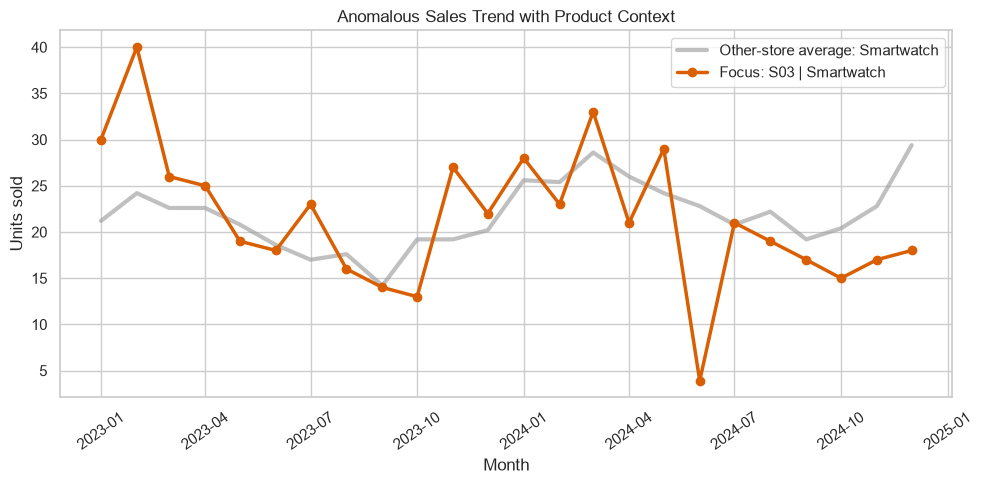

Top anomaly: S03 | Smartwatch (min/median = 0.186)


In [8]:
# --- Part B: drill-down with context preserved ---
overview_trends = (
    sales_df.groupby(["month", "store_id", "product"], as_index=False)["units_sold"]
    .sum()
)
overview_trends["series"] = overview_trends["store_id"] + " | " + overview_trends["product"]

anomaly_overview = px.line(
    overview_trends,
    x="month",
    y="units_sold",
    color="series",
    hover_data={"store_id": True, "product": True, "series": False},
    title="Monthly Unit Sales for Every Store and Product",
    labels={"units_sold": "Units sold", "month": "Month"},
)
anomaly_overview.update_layout(height=620, showlegend=False)
anomaly_overview.show()

top_anomaly = anomaly_ranking.iloc[0]
anomalous_store = top_anomaly["store_id"]
anomalous_product = top_anomaly["product"]

focus_trend = sales_df[
    (sales_df.store_id == anomalous_store) & (sales_df["product"] == anomalous_product)
].groupby("month", as_index=False).units_sold.sum()

context_trend = sales_df[
    (sales_df.store_id != anomalous_store) & (sales_df["product"] == anomalous_product)
].groupby("month", as_index=False).units_sold.mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(context_trend.month, context_trend.units_sold, color="#9e9e9e", lw=3, alpha=0.65, label=f"Other-store average: {anomalous_product}")
ax.plot(focus_trend.month, focus_trend.units_sold, color="#d95f02", marker="o", lw=2.5, label=f"Focus: {anomalous_store} | {anomalous_product}")
ax.set_title("Anomalous Sales Trend with Product Context")
ax.set_xlabel("Month")
ax.set_ylabel("Units sold")
ax.legend()
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

print(f"Top anomaly: {anomalous_store} | {anomalous_product} (min/median = {top_anomaly['min_to_median_ratio']:.3f})")

**Reflection:** I used hover to identify the anomalous store-product line in the dense overview. I then investigated it with an in-place focus-and-context chart that can be read by eye without replacing the dashboard window. Using hover only when the overview raised a question follows the rule of paying a higher interaction cost only when more evidence is needed.


## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [9]:
product_summary = (
    sales_df.groupby("product", as_index=False)
    .agg(revenue=("revenue", "sum"), profit=("profit", "sum"), avg_rating=("avg_rating", "mean"))
    .sort_values("revenue", ascending=False)
)

revenue_sorted_table = (
    product_summary.style
    .format({"revenue": "INR {:,.0f}", "profit": "INR {:,.0f}", "avg_rating": "{:.2f}"})
    .bar(subset=["revenue"], color="#86b6d8")
    .bar(subset=["profit"], color="#91c788")
    .bar(subset=["avg_rating"], color="#f4b183", vmin=0, vmax=5)
    .set_caption("UrbanCart Product Performance Sorted by Revenue")
)
revenue_sorted_table

,product,revenue,profit,avg_rating
5,Smartwatch,"INR 15,706,358","INR 3,881,507",4.09
0,Air Fryer,"INR 10,901,274","INR 2,593,731",4.04
4,Running Shoes,"INR 9,688,731","INR 2,303,075",4.10
2,Dumbbell Set,"INR 7,796,880","INR 1,829,127",4.11
1,Blender,"INR 7,648,773","INR 1,860,309",4.04
6,Track Jacket,"INR 6,992,502","INR 1,610,283",4.13
7,USB-C Hub,"INR 3,842,442","INR 907,435",4.09
8,Wireless Earbuds,"INR 3,769,985","INR 890,554",4.09
3,Laptop Sleeve,"INR 2,801,284","INR 664,358",4.08
9,Yoga Mat,"INR 1,560,447","INR 370,892",4.07


In [10]:
profit_sorted_summary = product_summary.sort_values("profit", ascending=False)
profit_sorted_table = (
    profit_sorted_summary.style
    .format({"revenue": "INR {:,.0f}", "profit": "INR {:,.0f}", "avg_rating": "{:.2f}"})
    .bar(subset=["revenue"], color="#86b6d8")
    .bar(subset=["profit"], color="#91c788")
    .bar(subset=["avg_rating"], color="#f4b183", vmin=0, vmax=5)
    .set_caption("UrbanCart Product Performance Sorted by Profit")
)
profit_sorted_table

,product,revenue,profit,avg_rating
5,Smartwatch,"INR 15,706,358","INR 3,881,507",4.09
0,Air Fryer,"INR 10,901,274","INR 2,593,731",4.04
4,Running Shoes,"INR 9,688,731","INR 2,303,075",4.10
1,Blender,"INR 7,648,773","INR 1,860,309",4.04
2,Dumbbell Set,"INR 7,796,880","INR 1,829,127",4.11
6,Track Jacket,"INR 6,992,502","INR 1,610,283",4.13
7,USB-C Hub,"INR 3,842,442","INR 907,435",4.09
8,Wireless Earbuds,"INR 3,769,985","INR 890,554",4.09
3,Laptop Sleeve,"INR 2,801,284","INR 664,358",4.08
9,Yoga Mat,"INR 1,560,447","INR 370,892",4.07


**Your observation (revenue-sorted vs profit-sorted top rows):**

The top rows do not keep exactly the same order after sorting by profit. A product can produce high revenue but rank lower on profit because the realized margin differs, so a manager should compare both measures before treating sales volume as financial performance.


## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


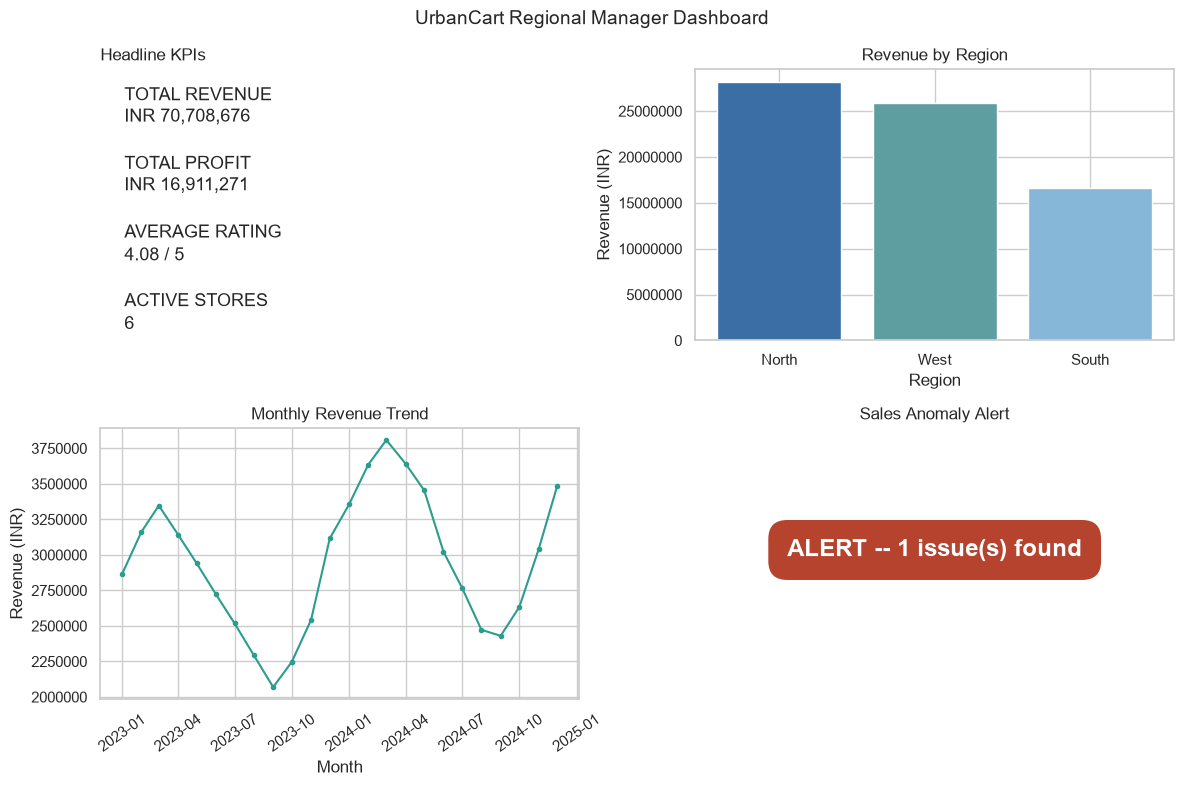

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Panel 1: KPI summary (top-left) ---
axes[0, 0].axis("off")
kpi_text = (
    f"TOTAL REVENUE\nINR {sales_df.revenue.sum():,.0f}\n\n"
    f"TOTAL PROFIT\nINR {sales_df.profit.sum():,.0f}\n\n"
    f"AVERAGE RATING\n{sales_df.avg_rating.mean():.2f} / 5\n\n"
    f"ACTIVE STORES\n{sales_df.store_id.nunique()}"
)
axes[0, 0].text(0.05, 0.95, kpi_text, va="top", ha="left", fontsize=13, linespacing=1.35)
axes[0, 0].set_title("Headline KPIs", loc="left")

# --- Panel 2: revenue by region (top-right) ---
region_revenue = sales_df.groupby("region", as_index=False).revenue.sum().sort_values("revenue", ascending=False)
axes[0, 1].bar(region_revenue.region, region_revenue.revenue, color=["#3b6ea5", "#5f9ea0", "#86b6d8"])
axes[0, 1].set_title("Revenue by Region")
axes[0, 1].set_xlabel("Region")
axes[0, 1].set_ylabel("Revenue (INR)")
axes[0, 1].ticklabel_format(style="plain", axis="y")

# --- Panel 3: total revenue by month, all stores (bottom-left) ---
monthly_revenue = sales_df.groupby("month", as_index=False).revenue.sum()
axes[1, 0].plot(monthly_revenue.month, monthly_revenue.revenue, color="#2a9d8f", marker="o", ms=3)
axes[1, 0].set_title("Monthly Revenue Trend")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Revenue (INR)")
axes[1, 0].tick_params(axis="x", rotation=35)
axes[1, 0].ticklabel_format(style="plain", axis="y")

# --- Panel 4: peripheral alert panel (bottom-right) ---
pair_medians = sales_df.groupby(["store_id", "product"])["units_sold"].transform("median")
alert_rows = sales_df[sales_df.units_sold < 0.25 * pair_medians]
issue_count = len(alert_rows)
axes[1, 1].axis("off")
if issue_count:
    alert_text, alert_color = f"ALERT -- {issue_count} issue(s) found", "#b5432e"
else:
    alert_text, alert_color = "OK -- no sales anomalies", "#2e7d32"
axes[1, 1].text(0.5, 0.55, alert_text, ha="center", va="center", fontsize=17, fontweight="bold", color="white", bbox={"boxstyle": "round,pad=0.8", "facecolor": alert_color, "edgecolor": "none"})
axes[1, 1].set_title("Sales Anomaly Alert")

fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=14)
plt.tight_layout()
plt.show()

## Reflection

1. Coordinated views with brushing would save the most time because a manager can select one store once and see its standing, category mix, and trend without opening separate reports or repeating filters.
2. The anomaly drill-down was the hardest to implement well because the 60-line overview preserves coverage but creates clutter. I had to balance context against readability and use hover plus muted comparison lines to keep the detailed view legible.
3. A magic lens would be useful over the monthly sales trend. Moving it across a date could reveal store- and product-level detail for that period while preserving the full two-year trend around it.